# Name : Amey Shendre
# Class : A-A2
# Roll : 26
## Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
df = pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
pd.set_option('display.float_format','{:.2f}'.format)

In [4]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81,USS Barnett\nFPO AP 44820
4,59982.20,5.04,7.84,4.23,26354.11,630943.49,USNS Raymond\nFPO AE 09386


In [5]:
if 'Address' in df.columns:
    df.drop(['Address'], axis=1, inplace=True)

In [6]:
X = df[['Avg. Area Income']]
y = df['Price']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

In [8]:
slr_model = LinearRegression()
slr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = slr_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

print("Simple Linear Regression")
print("-------------------------")
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("R2 Score: ",r2_score(y_test, y_pred))

Simple Linear Regression
-------------------------
MAE:  216826.3530998906
MSE:  74194887058.66
RMSE:  272387.38417676394
R2 Score:  0.39694865192619766


In [11]:
print("Intercept: ", slr_model.intercept_)
print("Slope: ",slr_model.coef_[0])

Intercept:  -225053.70287170215
Slope:  21.208906292657524


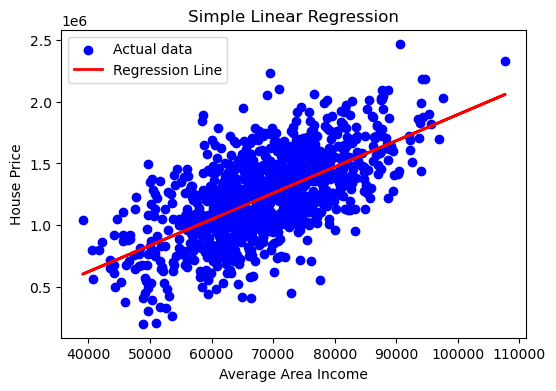

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(X_test,y_test, color='blue',label='Actual data')
plt.plot(X_test, y_pred,color='red', linewidth=2,label='Regression Line')
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [ ]:
income = float(input("Enter Average Area Income: "))
new_data = pd.DataFrame([[income]], columns=['Avg. Area Income'])
prediction = slr_model.predict(new_data)


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
lr = LinearRegression()

In [ ]:
lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

In [ ]:
grid_search = GridSearchCV(
    estimator = lr,
    param_grid = lr_params,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [ ]:
grid_search.fit(X_train, y_train)
print("Best Parameters: ")
print(grid_search.best_params_)

In [ ]:
print("Best Cross Validation Score: ")
print(grid_search.best_score_)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2 Score: ",r2)

In [ ]:
print(best_model)

# Ridge Regression

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("default Ridge R2 : " , r2_score(y_test, ridge_pred))

In [ ]:
param_grid ={'alpha': [0.001,0.01,0.1,1,10,100]}

In [ ]:
grid_ridge = GridSearchCV(estimator = Ridge(),param_grid = param_grid,scoring='r2',cv=5)

In [ ]:
grid_ridge.fit(X_train, y_train)

In [ ]:
print("Best Alpha: ", grid_ridge.best_params_)

In [ ]:
print(grid_ridge.best_score_)

In [ ]:
best_ridge =grid_ridge.best_estimator_

ridge_pred = best_ridge.predict(X_test)

In [ ]:
print("MAE : ", mean_absolute_error(y_test,ridge_pred))

print("MSE : ", mean_squared_error(y_test,ridge_pred))

print("RMSE : ", np.sqrt(mean_squared_error(y_test,ridge_pred)))

print("R2 :" ,r2_score(y_test,ridge_pred))

# Lasso regression

In [ ]:
from sklearn.linear_model import Lasso
param_grid ={'alpha': [0.001,0.01,0.1,1,10,100]}

In [ ]:
grid_lasso = GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(X_train,y_train)

In [ ]:
print(grid_lasso.best_params_)

In [ ]:
lasso_pred = grid_lasso.predict(X_test)

In [ ]:
print("MAE : ", mean_absolute_error(y_test, lasso_pred))

print("MSE : ", mean_squared_error(y_test, lasso_pred))

print("RMSE : ", np.sqrt(mean_squared_error(y_test, lasso_pred)))

print("R2 :" ,r2_score(y_test, lasso_pred))

In [ ]:
predictions =slr_model.predict(X_test)

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=predictions, color='blue', label='Predictions')

# Add a reference line(perfect prediction line)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Perfect Fit')

# Add label and legend
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

In [ ]:
mlr_model = LinearRegression()
mlr_model.fit(df.drop('Price', axis=1), df['Price'])

income = float(input("Enter average area income "))
house_age = float(input("Enter average area house age "))
rooms = float(input("Enter average area number of rooms "))
bedrooms = float(input("Enter average area number of bedrooms "))
population = float(input("Enter area population "))

#create input array
test_input = np.array([[income,house_age,rooms,bedrooms,population]])

#predict price
predicted_price = mlr_model.predict(test_input)

#display
print("Predicted House Price = ${:,.2f}".format(predicted_price[0]))

In [ ]:
# GitHUb repo: https://github.com/ShreyasKurhekar/ML-Practical-2